24i-2607
lab02
Ahmed iftikhar

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


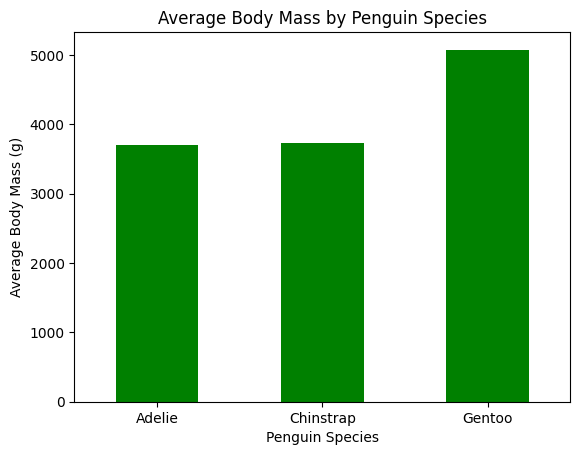

In [2]:
#task 01
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

penguins = sns.load_dataset("penguins")
print(penguins.head())

avg_mass = penguins.groupby("species")["body_mass_g"].mean()
avg_mass.plot(kind="bar",color='Green')

plt.xlabel("Penguin Species")
plt.ylabel("Average Body Mass (g)")
plt.title("Average Body Mass by Penguin Species")
plt.xticks(rotation=0)
plt.show()


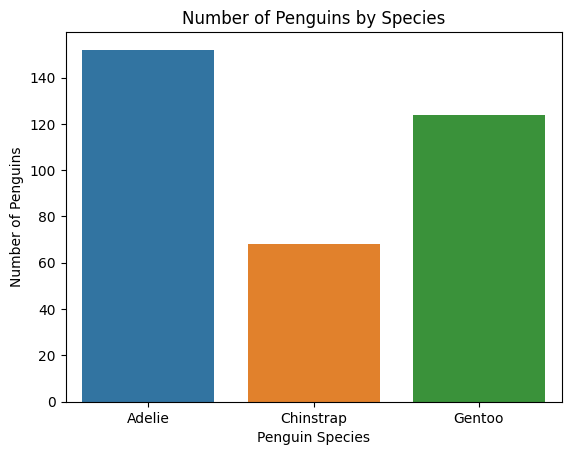

In [3]:
#task 02
sns.countplot(data=penguins, x="species")

plt.xlabel("Penguin Species")
plt.ylabel("Number of Penguins")
plt.title("Number of Penguins by Species")
plt.xticks(rotation=0)
plt.show()


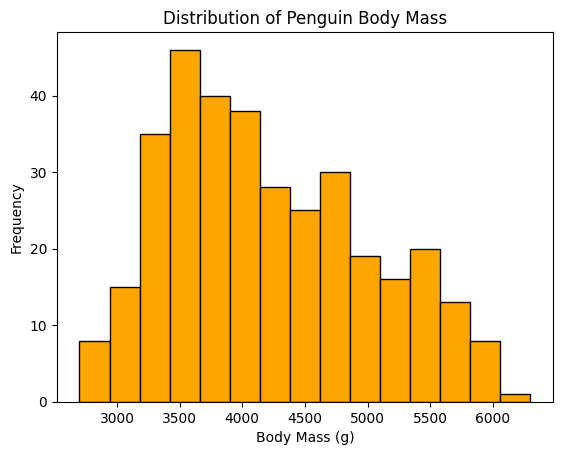

In [4]:
#task 03
plt.hist(penguins["body_mass_g"].dropna(), bins=15, edgecolor="black",color='orange')

plt.xlabel("Body Mass (g)")
plt.ylabel("Frequency")
plt.title("Distribution of Penguin Body Mass")

plt.show()


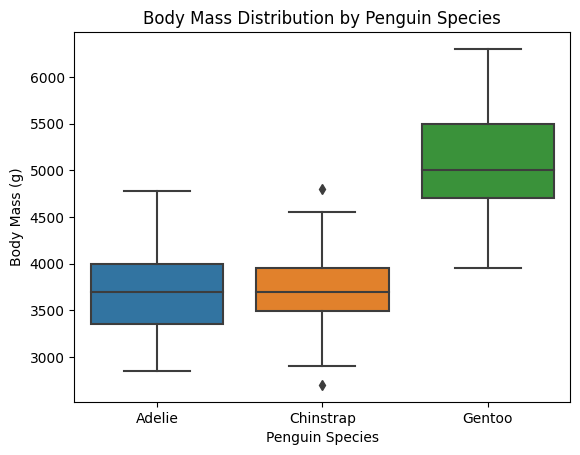

In [5]:
#task04
sns.boxplot(data=penguins, x="species", y="body_mass_g")

plt.xlabel("Penguin Species")
plt.ylabel("Body Mass (g)")
plt.title("Body Mass Distribution by Penguin Species")
plt.show()


In [6]:
#task 05

for species, group in penguins.groupby("species"):
    Q1 = group["body_mass_g"].quantile(0.25)
    Q3 = group["body_mass_g"].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = group[
        (group["body_mass_g"] < lower) |
        (group["body_mass_g"] > upper)
    ]
    
    print(species, "outliers:", len(outliers))


Adelie outliers: 0
Chinstrap outliers: 2
Gentoo outliers: 0


In [12]:
#task 06
from scipy import stats

for species, group in penguins.groupby("species"):
    group = group.copy()
    
    Q1 = group["body_mass_g"].quantile(0.25)
    Q3 = group["body_mass_g"].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers_iqr = group[
        (group["body_mass_g"] < lower) |
        (group["body_mass_g"] > upper)
    ]
    
    
    group["zscore"] = stats.zscore(
        group["body_mass_g"],
        nan_policy="omit"
    )
    
    outliers_z = group[group["zscore"].abs() > 3]
    
    print(
        species,
        "| IQR outliers:", len(outliers_iqr),
        "| Z-score outliers:", len(outliers_z)
    )


Adelie | IQR outliers: 0 | Z-score outliers: 0
Chinstrap | IQR outliers: 2 | Z-score outliers: 0
Gentoo | IQR outliers: 0 | Z-score outliers: 0


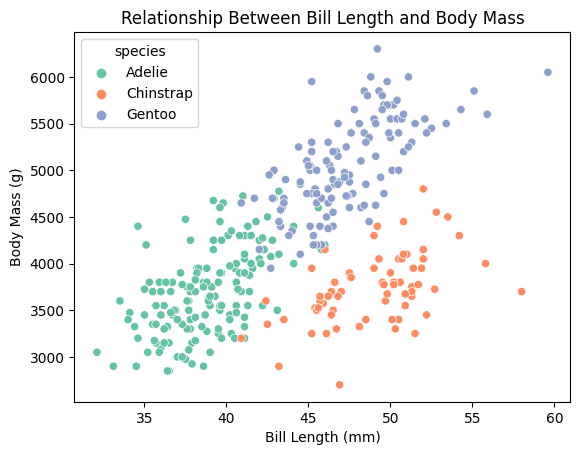

In [20]:
#task 07

sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="body_mass_g",
    hue="species",
    palette="Set2"
)

plt.xlabel("Bill Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Relationship Between Bill Length and Body Mass")
plt.show()


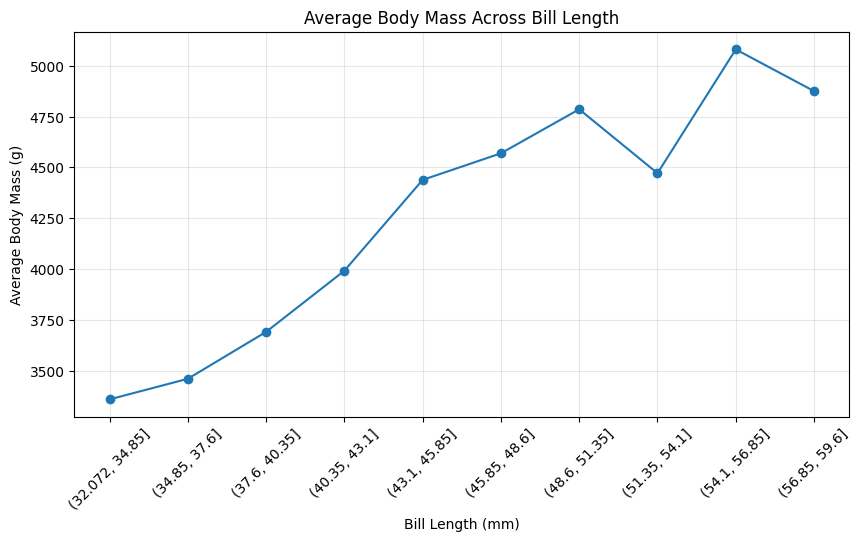

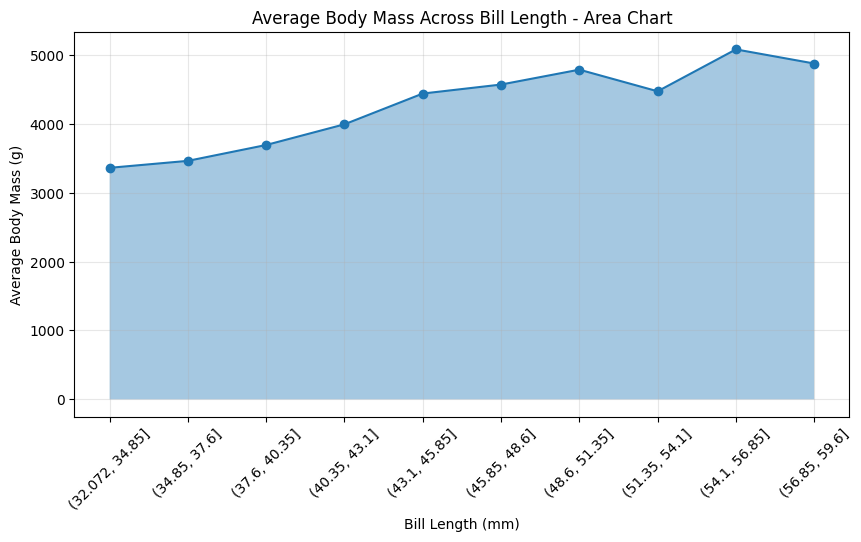

In [18]:
# Task 08

penguins["bill_length_bin"] = pd.cut(
    penguins["bill_length_mm"],
    bins=10
)

avg_mass = penguins.groupby(
    "bill_length_bin",
    observed=True
)["body_mass_g"].mean()

x = avg_mass.index.astype(str)
y = avg_mass.values

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker="o")

plt.xlabel("Bill Length (mm)")
plt.ylabel("Average Body Mass (g)")
plt.title("Average Body Mass Across Bill Length")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.fill_between(range(len(y)), y, alpha=0.4)
plt.plot(range(len(y)), y, marker="o")

plt.xlabel("Bill Length (mm)")
plt.ylabel("Average Body Mass (g)")
plt.title("Average Body Mass Across Bill Length - Area Chart")
plt.xticks(range(len(x)), x, rotation=45)
plt.grid(True, alpha=0.3)
plt.show()


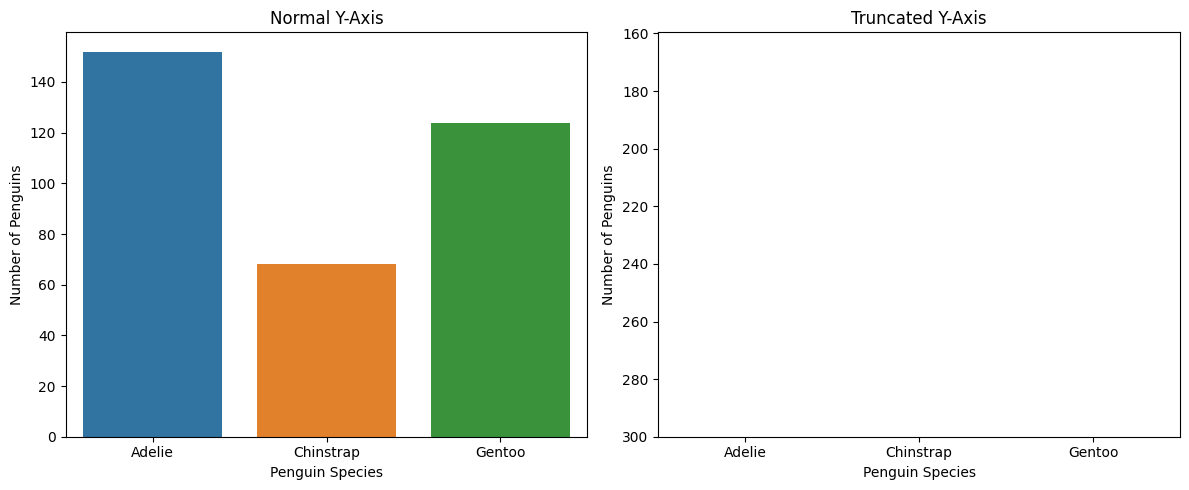

In [22]:
# Task 09

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=penguins, x="species", ax=axes[0])

axes[0].set_xlabel("Penguin Species")
axes[0].set_ylabel("Number of Penguins")
axes[0].set_title("Normal Y-Axis")
axes[0].set_ylim(bottom=0)


sns.countplot(data=penguins, x="species", ax=axes[1])

axes[1].set_xlabel("Penguin Species")
axes[1].set_ylabel("Number of Penguins")
axes[1].set_title("Truncated Y-Axis")
axes[1].set_ylim(bottom=300)

plt.tight_layout()
plt.show()

